In [1]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [17]:
!pip install wfdb

# Step 1: Organize ECG files into ecg_data folder
import os
import shutil
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, roc_curve, auc
from sklearn.preprocessing import label_binarize
import numpy as np # Ensure numpy is imported



In [5]:

os.makedirs("ecg_data", exist_ok=True)
for filename in os.listdir("/content"):
    if filename.endswith(('.dat', '.atr', '.hea', '.xws')):
        shutil.move(os.path.join("/content", filename), "ecg_data")
print("Files moved to ecg_data:", os.listdir("ecg_data"))

Files moved to ecg_data: ['213.hea', '113.dat', '115.dat', '215.xws', '201.hea', '122.xws', '219.xws', '210.hea', '119.dat', '115.atr', '200.xws', '209.atr', '208.dat', '207.xws', '111.atr', '232.hea', '100.dat', '104.xws', '212.dat', '233.dat', '109.hea', '102.dat', '228.xws', '121.atr', '213.dat', '223.xws', '202.atr', '210.dat', '234.hea', '119.xws', '234.dat', '114.atr', '213.xws', '101.atr', '213.atr', '105.xws', '108.atr', '223.hea', '230.atr', '106.atr', '113.atr', '208.xws', '234.atr', '101.xws', '103.atr', '106.dat', '231.hea', '231.xws', '109.xws', '124.atr', '210.xws', '228.dat', '116.atr', '215.atr', '205.atr', '105.dat', '112.dat', '119.atr', '102.xws', '215.dat', '207.dat', '221.xws', '222.xws', '123.hea', '233.xws', '217.atr', '230.hea', '233.atr', '121.hea', '217.xws', '113.xws', '114.xws', '118.atr', '202.hea', '122.hea', '121.xws', '221.hea', '212.hea', '117.atr', '203.dat', '208.atr', '221.atr', '100.xws', '221.dat', '115.xws', '220.xws', '212.xws', '208.hea', '231.d

In [6]:
# Step 2: Load ECG Records
import wfdb

data_dir = "ecg_data"
record_names = sorted(set(f.split('.')[0] for f in os.listdir(data_dir) if f.endswith('.dat')))
print("Found records:", record_names)

# Read sample
sample_record = wfdb.rdrecord(os.path.join(data_dir, record_names[0]))
sample_annotation = wfdb.rdann(os.path.join(data_dir, record_names[0]), 'atr')
print("Sample data shape:", sample_record.p_signal.shape)
print("Annotation symbols:", sample_annotation.symbol[:10])


Found records: ['100', '101', '102', '103', '104', '105', '106', '107', '108', '109', '111', '112', '113', '114', '115', '116', '117', '118', '119', '121', '122', '123', '124', '200', '201', '202', '203', '205', '207', '208', '209', '210', '212', '213', '214', '215', '217', '219', '220', '221', '222', '223', '228', '230', '231', '232', '233', '234']
Sample data shape: (650000, 2)
Annotation symbols: ['+', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'A', 'N']


In [7]:
# Step 3: Extract R-peaks and beats
import numpy as np

all_beats, all_labels = [], []
window_size = 100

for record_name in record_names:
    try:
        record = wfdb.rdrecord(f'{data_dir}/{record_name}')
        annotation = wfdb.rdann(f'{data_dir}/{record_name}', 'atr')
        signal = record.p_signal[:, 0]
        r_peaks, labels = annotation.sample, annotation.symbol

        for i in range(len(r_peaks)):
            idx = r_peaks[i]
            if idx - window_size > 0 and idx + window_size < len(signal):
                beat = signal[idx - window_size: idx + window_size]
                all_beats.append(beat)
                all_labels.append(labels[i])
    except Exception as e:
        print(f"Failed to process {record_name}: {e}")

In [8]:

# Step 4: Filter and encode labels
from sklearn.preprocessing import LabelEncoder

allowed_labels = ['N', 'A', 'V', 'L', 'R']
filtered_beats = [beat for beat, label in zip(all_beats, all_labels) if label in allowed_labels]
filtered_labels = [label for label in all_labels if label in allowed_labels]

X = np.array(filtered_beats)
y = np.array(filtered_labels)

label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)
print("Encoded Classes:", label_encoder.classes_)

Encoded Classes: ['A' 'L' 'N' 'R' 'V']


In [9]:

# Step 5: Train/Validation/Test split (70/15/15)
from sklearn.model_selection import train_test_split

# Ensure X has the correct shape for CNN/DenseNet (samples, timesteps, features)
X_reshaped = X.reshape(X.shape[0], X.shape[1], 1)

# Split for CNN/DenseNet
X_temp, X_test, y_temp, y_test = train_test_split(X_reshaped, y_encoded, test_size=0.15, stratify=y_encoded, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.176, stratify=y_temp, random_state=42)  # 0.176 * 0.85 ≈ 0.15

print(f"Train: {len(X_train)}, Val: {len(X_val)}, Test: {len(X_test)}")

Train: 70063, Val: 14965, Test: 15005


In [10]:
# Step 6: Define DenseNet model and train
import tensorflow as tf
from tensorflow.keras import layers, models, Input
from sklearn.metrics import accuracy_score

def dense_block(x, num_convs, growth_rate):
    for _ in range(num_convs):
        out = layers.BatchNormalization()(x)
        out = layers.ReLU()(out)
        out = layers.Conv1D(growth_rate, kernel_size=3, padding='same')(out)
        x = layers.Concatenate()([x, out])
    return x

def transition_layer(x, reduction):
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    x = layers.Conv1D(int(x.shape[-1] * reduction), kernel_size=1)(x)
    x = layers.AveragePooling1D(pool_size=2, strides=2)(x)
    return x

input_shape = (X_reshaped.shape[1], 1)
inputs = Input(shape=input_shape)
x = layers.Conv1D(16, kernel_size=7, strides=2, padding='same')(inputs)
x = layers.BatchNormalization()(x)
x = layers.ReLU()(x)
x = layers.MaxPooling1D(pool_size=3, strides=2, padding='same')(x)

x = dense_block(x, num_convs=4, growth_rate=12)
x = transition_layer(x, reduction=0.5)
x = dense_block(x, num_convs=4, growth_rate=12)
x = transition_layer(x, reduction=0.5)

x = layers.GlobalAveragePooling1D()(x)
x = layers.Dense(64, activation='relu')(x)
outputs = layers.Dense(len(label_encoder.classes_), activation='softmax')(x)

densenet_model = models.Model(inputs=inputs, outputs=outputs)
densenet_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

print("\n--- Training DenseNet Model ---")
history = densenet_model.fit(X_train, y_train, epochs=15, batch_size=32, validation_data=(X_val, y_val), verbose=0)
densenet_val_accuracy = densenet_model.evaluate(X_val, y_val, verbose=0)[1]
print(f"DenseNet Validation Accuracy: {densenet_val_accuracy:.4f}")


--- Training DenseNet Model ---
DenseNet Validation Accuracy: 0.9877


In [11]:
# NEW: Step 6.1: Define and Train a Standalone CNN Model
def create_cnn_model(input_shape, num_classes):
    model = models.Sequential([
        layers.Conv1D(32, kernel_size=5, activation='relu', input_shape=input_shape),
        layers.MaxPooling1D(pool_size=2),
        layers.Conv1D(64, kernel_size=3, activation='relu'),
        layers.MaxPooling1D(pool_size=2),
        layers.Flatten(),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(num_classes, activation='softmax')
    ])
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

cnn_model = create_cnn_model(input_shape, len(label_encoder.classes_))
print("\n--- Training Standalone CNN Model ---")
cnn_model.fit(X_train, y_train, epochs=15, batch_size=32, validation_data=(X_val, y_val), verbose=0)
cnn_val_accuracy = cnn_model.evaluate(X_val, y_val, verbose=0)[1]
print(f"Standalone CNN Validation Accuracy: {cnn_val_accuracy:.4f}")# NEW: Step 6.1: Define and Train a Standalone CNN Model
def create_cnn_model(input_shape, num_classes):
    model = models.Sequential([
        layers.Conv1D(32, kernel_size=5, activation='relu', input_shape=input_shape),
        layers.MaxPooling1D(pool_size=2),
        layers.Conv1D(64, kernel_size=3, activation='relu'),
        layers.MaxPooling1D(pool_size=2),
        layers.Flatten(),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(num_classes, activation='softmax')
    ])
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

cnn_model = create_cnn_model(input_shape, len(label_encoder.classes_))
print("\n--- Training Standalone CNN Model ---")
cnn_model.fit(X_train, y_train, epochs=15, batch_size=32, validation_data=(X_val, y_val), verbose=0)
cnn_val_accuracy = cnn_model.evaluate(X_val, y_val, verbose=0)[1]
print(f"Standalone CNN Validation Accuracy: {cnn_val_accuracy:.4f}")

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



--- Training Standalone CNN Model ---
Standalone CNN Validation Accuracy: 0.9902

--- Training Standalone CNN Model ---
Standalone CNN Validation Accuracy: 0.9914


In [12]:
# Step 7: Train Random Forest
from sklearn.ensemble import RandomForestClassifier

# For Random Forest, flatten the input features
X_rf = X.reshape(X.shape[0], -1)

# Ensure RF splits are consistent with previous splits for fair comparison
# We need to flatten X_train, X_val, X_test for RF
X_rf_train = X_train.reshape(X_train.shape[0], -1)
X_rf_val = X_val.reshape(X_val.shape[0], -1)
X_rf_test = X_test.reshape(X_test.shape[0], -1)


rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
print("\n--- Training Random Forest Model ---")
rf_model.fit(X_rf_train, y_train) # Use y_train directly
rf_val_accuracy = rf_model.score(X_rf_val, y_val) # Use y_val directly
print(f"Random Forest Validation Accuracy: {rf_val_accuracy:.4f}")


--- Training Random Forest Model ---
Random Forest Validation Accuracy: 0.9829



--- Evaluating Hybrid Model (DenseNet + Standalone CNN) ---
469/469 ━━━━━━━━━━━━━━━━━━━━ 7s 14ms/step
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step


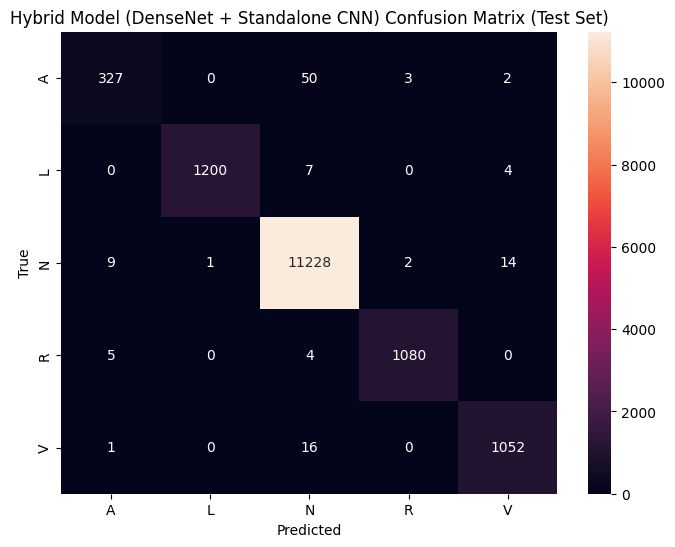

Hybrid (DenseNet + Standalone CNN) Classification Report (Test Set):
              precision    recall  f1-score   support

           A       0.96      0.86      0.90       382
           L       1.00      0.99      1.00      1211
           N       0.99      1.00      1.00     11254
           R       1.00      0.99      0.99      1089
           V       0.98      0.98      0.98      1069

    accuracy                           0.99     15005
   macro avg       0.99      0.96      0.97     15005
weighted avg       0.99      0.99      0.99     15005

Hybrid (DenseNet + Standalone CNN) Test Accuracy: 0.9921


In [14]:
# MODIFIED: Step 8: Hybrid Voting (Soft voting between DenseNet + Standalone CNN)
# THIS IS YOUR REQUESTED CNN + DENSENET HYBRID MODEL
# Import necessary libraries for evaluation and plotting
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np # Ensure numpy is imported if not already

print("\n--- Evaluating Hybrid Model (DenseNet + Standalone CNN) ---")
dense_probs = densenet_model.predict(X_test) # Probabilities from DenseNet
cnn_probs = cnn_model.predict(X_test)     # Probabilities from Standalone CNN

# Soft Voting: Average the probabilities from DenseNet and Standalone CNN
hybrid_cnn_densenet_probs = (dense_probs + cnn_probs) / 2.0
hybrid_cnn_densenet_preds = np.argmax(hybrid_cnn_densenet_probs, axis=1)

# Confusion Matrix and Classification Report for the CNN + DenseNet Hybrid
cm_cnn_densenet = confusion_matrix(y_test, hybrid_cnn_densenet_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_cnn_densenet, annot=True, fmt='d', xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.title("Hybrid Model (DenseNet + Standalone CNN) Confusion Matrix (Test Set)")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

print("Hybrid (DenseNet + Standalone CNN) Classification Report (Test Set):")
print(classification_report(y_test, hybrid_cnn_densenet_preds, target_names=label_encoder.classes_))
hybrid_cnn_densenet_test_accuracy = accuracy_score(y_test, hybrid_cnn_densenet_preds)
print(f"Hybrid (DenseNet + Standalone CNN) Test Accuracy: {hybrid_cnn_densenet_test_accuracy:.4f}")


# NEW: Step 8.1 (Optional): Keep the original DenseNet + RF Hybrid for comparison if needed
# If you still want to see the performance of the old DenseNet + RF hybrid, uncomment this block.
# print("\n--- Evaluating ORIGINAL Hybrid Model (DenseNet + RF) ---")
# dense_probs_orig = densenet_model.predict(X_test)
# rf_probs_orig = rf_model.predict_proba(X_rf_test)
# hybrid_orig_probs = (dense_probs_orig + rf_probs_orig) / 2.0
# hybrid_orig_preds = np.argmax(hybrid_orig_probs, axis=1)
# print("ORIGINAL Hybrid (DenseNet + RF) Classification Report (Test Set):")
# print(classification_report(y_test, hybrid_orig_preds, target_names=label_encoder.classes_))
# hybrid_orig_test_accuracy = accuracy_score(y_test, hybrid_orig_preds)
# print(f"ORIGINAL Hybrid (DenseNet + RF) Test Accuracy: {hybrid_orig_test_accuracy:.4f}")

In [15]:

# NEW: Step 9: Evaluate Individual Models on Test Set (This section remains unchanged)
print("\n--- Evaluating Individual Models on Test Set ---")

# DenseNet Test Accuracy
densenet_test_loss, densenet_test_accuracy = densenet_model.evaluate(X_test, y_test, verbose=0)
print(f"DenseNet Test Accuracy: {densenet_test_accuracy:.4f}")
densenet_preds = np.argmax(densenet_model.predict(X_test), axis=1)
print("DenseNet Classification Report (Test Set):")
print(classification_report(y_test, densenet_preds, target_names=label_encoder.classes_))

# Standalone CNN Test Accuracy
cnn_test_loss, cnn_test_accuracy = cnn_model.evaluate(X_test, y_test, verbose=0)
print(f"Standalone CNN Test Accuracy: {cnn_test_accuracy:.4f}")
cnn_preds = np.argmax(cnn_model.predict(X_test), axis=1)
print("Standalone CNN Classification Report (Test Set):")
print(classification_report(y_test, cnn_preds, target_names=label_encoder.classes_))

# Random Forest Test Accuracy
rf_test_accuracy = rf_model.score(X_rf_test, y_test)
print(f"Random Forest Test Accuracy: {rf_test_accuracy:.4f}")
rf_preds = rf_model.predict(X_rf_test)
print("Random Forest Classification Report (Test Set):")
print(classification_report(y_test, rf_preds, target_names=label_encoder.classes_))


--- Evaluating Individual Models on Test Set ---
DenseNet Test Accuracy: 0.9879
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step
DenseNet Classification Report (Test Set):
              precision    recall  f1-score   support

           A       0.88      0.87      0.88       382
           L       0.99      0.99      0.99      1211
           N       0.99      0.99      0.99     11254
           R       0.98      0.99      0.99      1089
           V       0.96      0.98      0.97      1069

    accuracy                           0.99     15005
   macro avg       0.96      0.96      0.96     15005
weighted avg       0.99      0.99      0.99     15005

Standalone CNN Test Accuracy: 0.9905
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step
Standalone CNN Classification Report (Test Set):
              precision    recall  f1-score   support

           A       0.96      0.80      0.87       382
           L       1.00      0.99      0.99      1211
           N       0.99      1.00      0.99     11254
 

In [16]:




# NEW: Step 10: Compare Accuracies (Updated to include the new hybrid model)
print("\n--- Model Accuracy Comparison (Test Set) ---")
print(f"Hybrid Model (DenseNet + Standalone CNN) Test Accuracy: {hybrid_cnn_densenet_test_accuracy:.4f}")
# If you uncommented Step 8.1, you can add this line too:
# print(f"ORIGINAL Hybrid Model (DenseNet + RF) Test Accuracy: {hybrid_orig_test_accuracy:.4f}")
print(f"DenseNet Only Test Accuracy: {densenet_test_accuracy:.4f}")
print(f"Standalone CNN Only Test Accuracy: {cnn_test_accuracy:.4f}")
print(f"Random Forest Only Test Accuracy: {rf_test_accuracy:.4f}")


--- Model Accuracy Comparison (Test Set) ---
Hybrid Model (DenseNet + Standalone CNN) Test Accuracy: 0.9921
DenseNet Only Test Accuracy: 0.9879
Standalone CNN Only Test Accuracy: 0.9905
Random Forest Only Test Accuracy: 0.9825



--- Generating Training History Plots ---


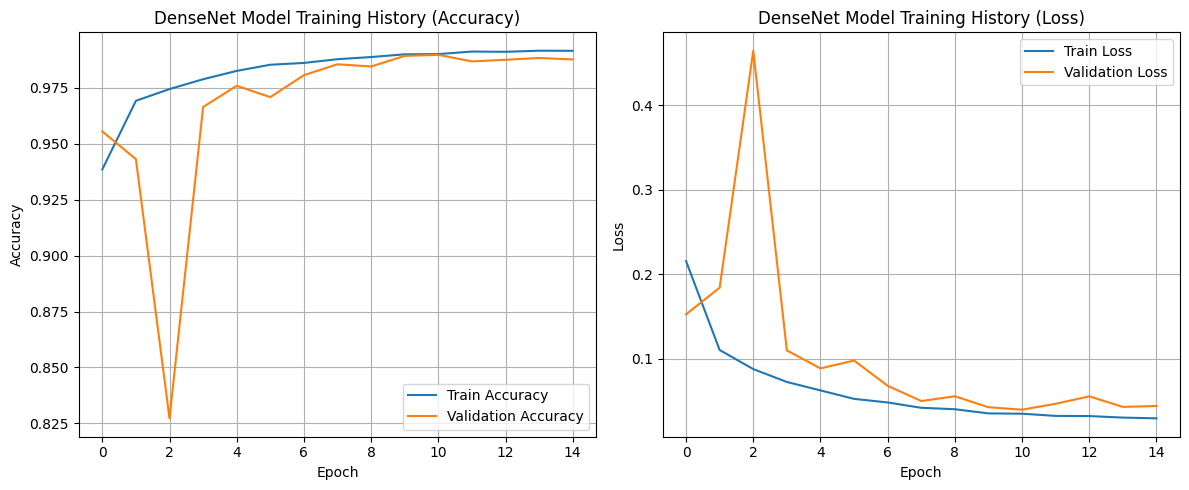

In [19]:
# --- GENERATING PLOTS FOR VISUALIZATION ---

# 1. Training History Plots (Accuracy & Loss) for DenseNet and Standalone CNN
print("\n--- Generating Training History Plots ---")

# DenseNet History Plot
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('DenseNet Model Training History (Accuracy)')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('DenseNet Model Training History (Loss)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()





--- Generating Confusion Matrices ---


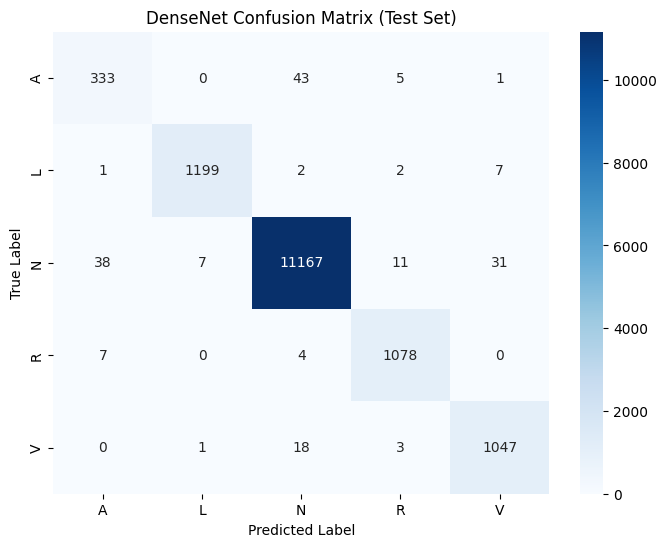

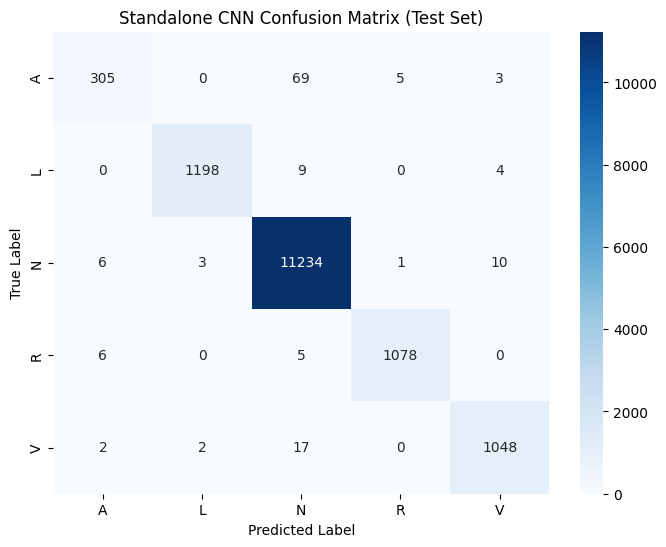

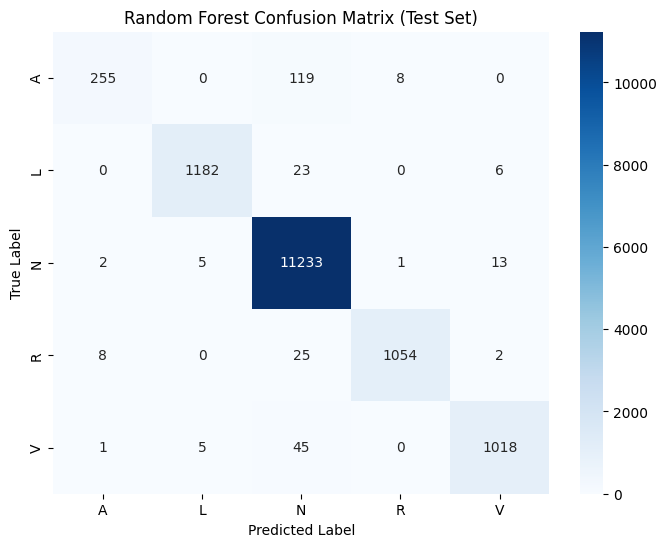

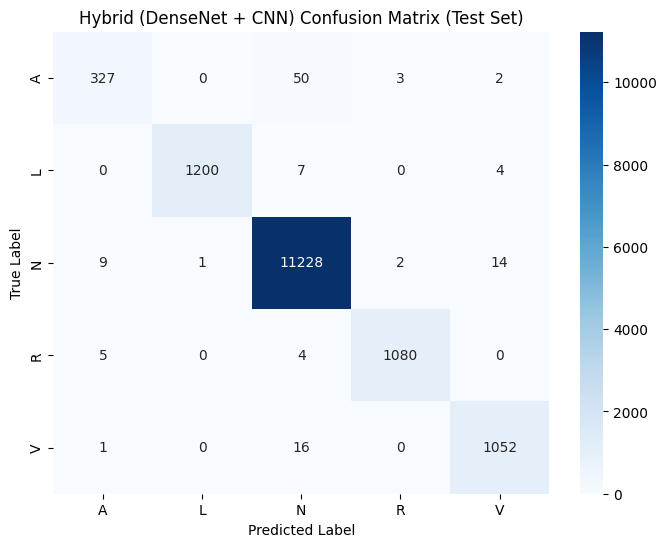

In [20]:
# 2. Confusion Matrices for all models on the Test Set
print("\n--- Generating Confusion Matrices ---")

models_and_preds = {
    "DenseNet": densenet_preds,
    "Standalone CNN": cnn_preds,
    "Random Forest": rf_preds,
    "Hybrid (DenseNet + CNN)": hybrid_cnn_densenet_preds
}

for model_name, predictions in models_and_preds.items():
    cm = confusion_matrix(y_test, predictions)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
    plt.title(f"{model_name} Confusion Matrix (Test Set)")
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.show()


--- Generating Model Comparison Bar Chart ---


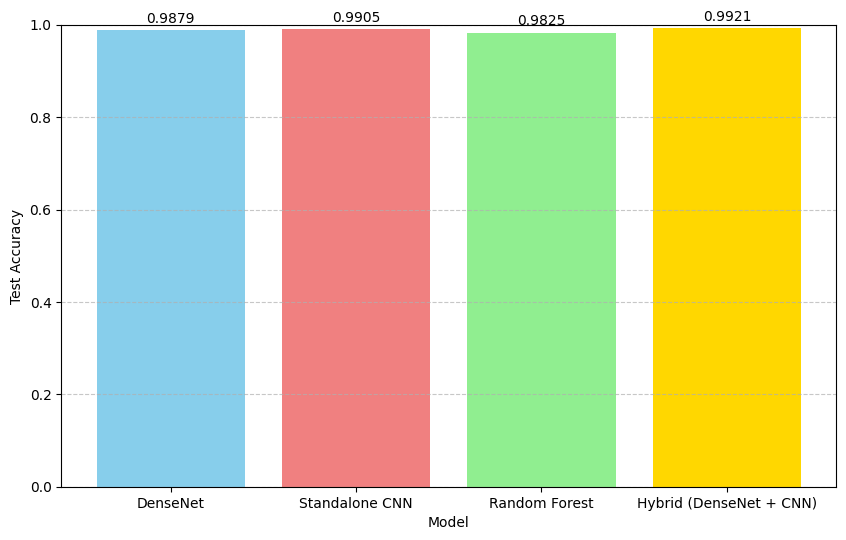

In [22]:
# 3. Model Comparison Bar Chart (Test Accuracy)
print("\n--- Generating Model Comparison Bar Chart ---")

model_accuracies = {
    "DenseNet": densenet_test_accuracy,
    "Standalone CNN": cnn_test_accuracy,
    "Random Forest": rf_test_accuracy,
    "Hybrid (DenseNet + CNN)": hybrid_cnn_densenet_test_accuracy
}

model_names = list(model_accuracies.keys())
accuracies = list(model_accuracies.values())

plt.figure(figsize=(10, 6))
bars = plt.bar(model_names, accuracies, color=['skyblue', 'lightcoral', 'lightgreen', 'gold'])
plt.xlabel("Model")
plt.ylabel("Test Accuracy")

plt.ylim(0, 1) # Accuracy is between 0 and 1

# Add accuracy values on top of bars
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.01, round(yval, 4), ha='center', va='bottom')

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()



--- Generating Multi-class ROC Curves ---
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step


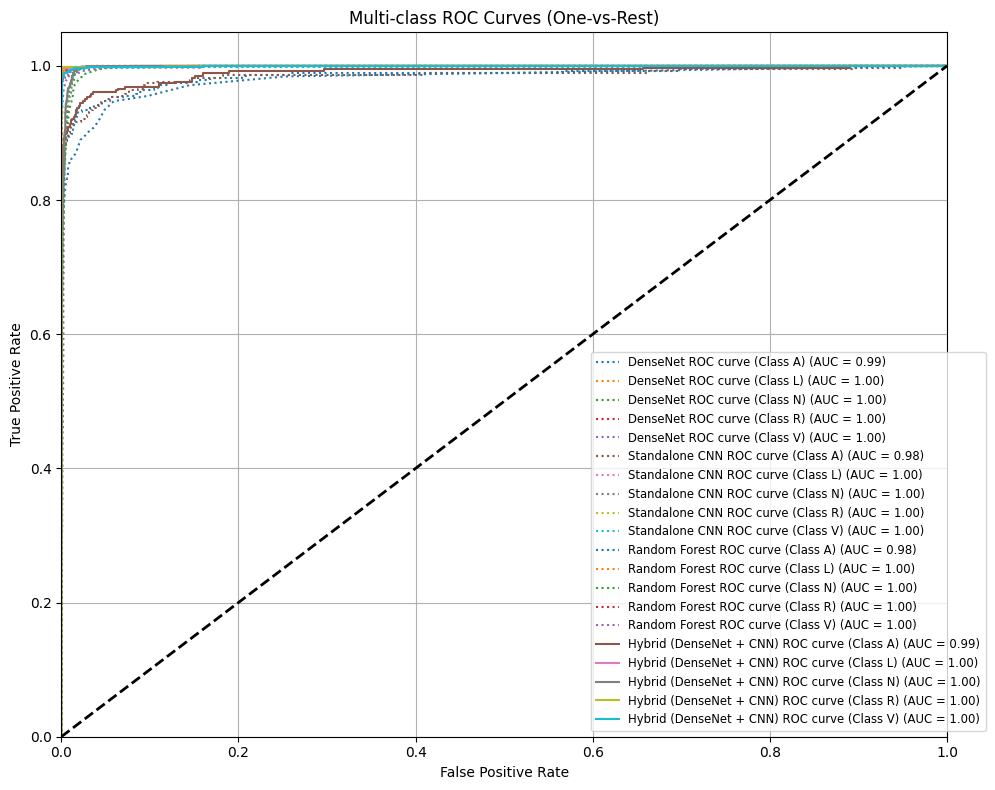

In [23]:
# 4. Multi-class ROC Curves (One-vs-Rest)
print("\n--- Generating Multi-class ROC Curves ---")

num_classes = len(label_encoder.classes_)
y_test_binarized = label_binarize(y_test, classes=range(num_classes))

models_and_probs = {
    "DenseNet": densenet_model.predict(X_test),
    "Standalone CNN": cnn_model.predict(X_test),
    "Random Forest": rf_model.predict_proba(X_rf_test),
    "Hybrid (DenseNet + CNN)": hybrid_cnn_densenet_probs
}

plt.figure(figsize=(10, 8))

for model_name, probabilities in models_and_probs.items():
    fpr = dict()
    tpr = dict()
    roc_auc = dict()
    for i in range(num_classes):
        fpr[i], tpr[i], _ = roc_curve(y_test_binarized[:, i], probabilities[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])

    # Plot all ROC curves for each class
    for i in range(num_classes):
        plt.plot(fpr[i], tpr[i], label=f'{model_name} ROC curve (Class {label_encoder.classes_[i]}) (AUC = {roc_auc[i]:.2f})',
                 linestyle=':' if model_name != "Hybrid (DenseNet + CNN)" else '-')

plt.plot([0, 1], [0, 1], 'k--', lw=2) # Random guess line
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Multi-class ROC Curves (One-vs-Rest)')
plt.legend(loc="lower right", fontsize='small', bbox_to_anchor=(1.05, 0)) # Adjust legend position
plt.grid(True)
plt.tight_layout()
plt.show()